# SOUS VIDE Examples Notebook
This notebook shows you how to generate two example policies from the SOUS VIDE paper; the policy flown for the robustness tests and the policy flown in the cluttered backroom.

Some useful settings for interactive work

In [1]:
%load_ext autoreload
%autoreload 2

%matplotlib widget

Import the relevant modules

In [1]:
import torch
torch.set_float32_matmul_precision('high')

import sousvide.synthesize.rollout_generator as rg
import sousvide.synthesize.observation_generator as og
import sousvide.instruct.train_policy as tp
import sousvide.visualize.plot_synthesize as ps
import sousvide.visualize.plot_learning as pl
import sousvide.flight.deploy_figs as df

#### 1. Define the desired scene and course to train on.

In [2]:
# =========================================
# Aerial Arena Test
# =========================================

# cohort = "aerial_arena"               # Cohort name (parent folder) for the robustness test
# scene = "aerialarena_square_16x/splatfacto/2026-08-06_013130_clean"                  # Scene name for the robustness test
# courses = ["aerialarena_test"]              # Courses to be used in the robustness test

# =========================================
# Robustness Test
# =========================================

cohort = "robustness"               # Cohort name (parent folder) for the robustness test
scene = "mid_gate"                  # Scene name for the robustness test
courses = ["traverse"]              # Courses to be used in the robustness test

# # =========================================
# # Cluttered Test
# # =========================================

# cohort = "cluttered"               # Cohort name (parent folder) for the cluttered test
# scene = "backroom"                  # Scene name for the cluttered test
# courses = ["circuit"]              # Courses to be used in the cluttered test

#### 2. Define the SOUS VIDE policy to train/evaluate.

Feel free to use Maverick as a reference to add more pilots in the configs/pilots folder. The configs allow users to create diverse variations of the policy without having to change package level code. We have an example of this (Iceman) where we remove velocity and height estimates.

Use data_alpha for your data method as a small initial test. It gives performance close to the published results within a shorter training time. Use data_beta/data_gamma to generate the actual policy (this takes longer, up to a day depending on your hardware setup).

Similarly, feel free to play with the eval methods according to their incremental difficulties.

In [3]:
# Pilot roster
roster = [
    "Maverick",
    # "Iceman"
    ]

# Data synthesis method.
# data_method = "data_alpha"          # Small data set for initial testing (use only to get a feel for the system).
data_method = "data_beta"           # Medium data set for training
# data_method = "data_gamma"          # Large data set for training

# Evaluation methods
# eval_method = "eval_single"         # Evaluate over a single trajectory, ideal frame and no noise.
eval_method = "eval_nominal"        # Evaluate over 10 trajectories, non-ideal frame and noise.
# eval_method = "eval_challenged"     # Evaluate over 10 trajectories, non-ideal frame and some noise.
# # eval_method = "eval_extreme"        # Evaluate over 10 trajectories after putting the drone and pilot through a washing machine.

# Event representations generated together from the same v2e stream.
event_surface_modalities = ("event_bin", "event_eros", "event_tos")
event_voxel_modalities = ("event_voxel_grid", "event_voxel_grid_polarity")
all_event_modalities = event_surface_modalities + event_voxel_modalities

# Surface defaults. Replace either assignment with a preset below as needed.
# event_modalities_to_generate = event_surface_modalities
# event_modalities_to_train = event_surface_modalities
# event_modalities_to_generate = event_voxel_modalities  # Generate 5/10-channel voxels.
# event_modalities_to_train = event_voxel_modalities     # Train both voxel models.
# event_modalities_to_generate = all_event_modalities    # Generate every representation.
# event_modalities_to_train = all_event_modalities       # Train every representation.
# Voxel inputs require an SVNet pilot such as Maverick or Iceman; DINO is RGB-only.
event_modalities_to_generate = ("event_eros", "kronecker_delta")
event_modalities_to_train = ("event_eros", "kronecker_delta")
# event_modalities_to_generate = ("event_pseudo_gaussian", "event_bilinear")
# event_modalities_to_train = ("event_pseudo_gaussian", "event_bilinear")
deployment_modality = event_modalities_to_train[0]
event_surface_options = {
    "event_eros": {"kernel_size": 7, "decay": 0.3},
    # "event_tos": {"kernel_size": 5, "parameter": 2.0},
    # "event_pseudo_gaussian": {"sigma": 1.0, "radius": 3},
    # "event_bilinear": {"sigma": 1.0, "radius": 2},
}
deployment_modality = event_modalities_to_train[0]

#### 3. Generate trajectory rollouts.

Trajectory rollouts are the raw data we extract from the simulation environment, FiGS. This comprises of images, states, inputs, external forces, drone parameters and their derivations.

We also output the ideal trajectory and the solved (ideal) keyframe times given the desired waypoints (course).

Use the given plot function to plot the rollout data. It gives some insight on the currently available rollout data within the cohort.

In [33]:
import numpy
torch.serialization.add_safe_globals([numpy.core.multiarray.scalar])

# Generate Rollout Data
rg.generate_rollout_data(
    cohort,courses,scene,data_method,generate_events=True,event_workers=10)

# Generate event representations from the saved raw event streams
# rg.generate_event_representations(
#     cohort,courses,event_modalities_to_generate,event_workers=10,
#     event_surface_options=event_surface_options)
# rg.generate_event_representations(
#     cohort,courses,event_modalities_to_generate,event_workers=10)

# cloud_options = {"num_points": 16384, "seed": 0}
# rg.generate_event_representations(
#     cohort_name=cohort,
#     course_names=courses,
#     event_modalities=("event_cloud",),
#     event_cloud_options=cloud_options,
#     event_workers=10,
# )

/mnt/ssd/SousVide/.venv/lib/python3.10/site-packages/torchmetrics/functional/image/lpips.py:293: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  self.load_state_dict(torch.load(model_path, map_location="cpu"), strict=False)


Loading latest checkpoint from load_dir

✅ Done loading checkpoint from outputs/mid_gate/splatfacto/2024-10-07_145741/nerfstudio_models/step-000029999.ckpt

Output()

 traverse - Ideal Time Steps: [ 0.     3.752  6.606  9.163 12.16  14.164]

...

Simulating vrmpc rollout:   0%|          | 0/200 [00:00<?, ?it/s]

Simulating vrmpc rollout:   0%|          | 0/200 [00:00<?, ?it/s]

Simulating vrmpc rollout:   0%|          | 0/200 [00:00<?, ?it/s]

Simulating vrmpc rollout:   0%|          | 0/200 [00:00<?, ?it/s]

Simulating vrmpc rollout:   0%|          | 0/200 [00:00<?, ?it/s]

Showing 50 samples from [traverse]>trajectories014.pt

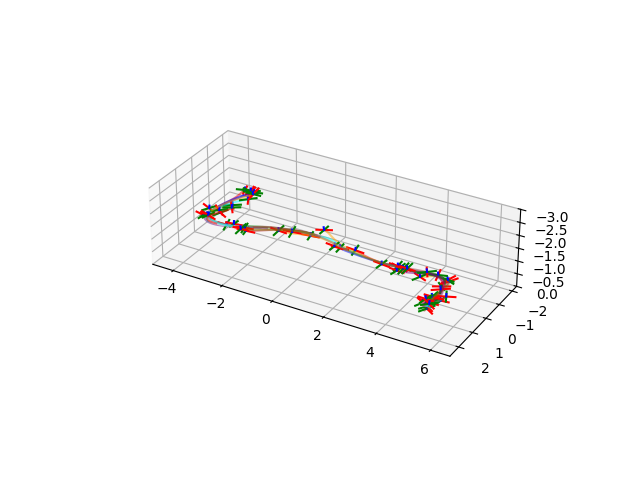

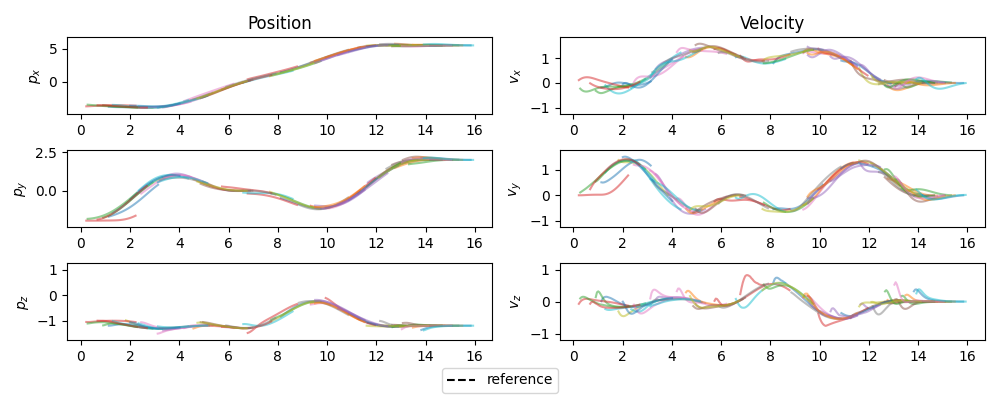

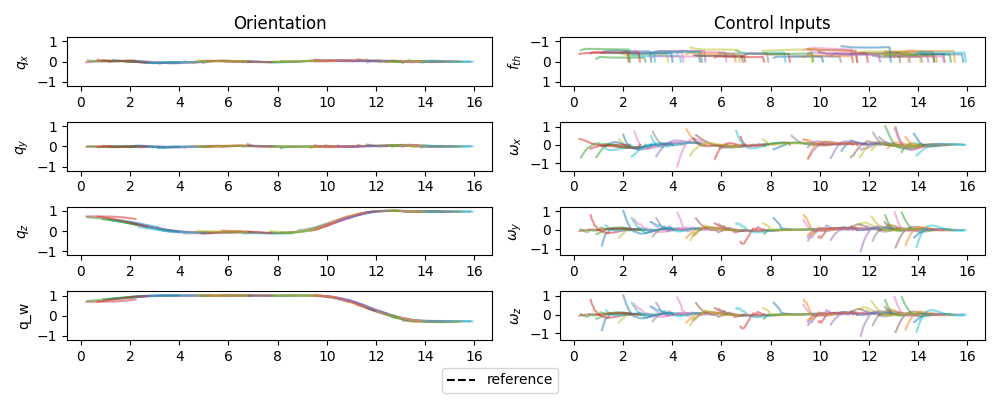

Rollout produced 29 datasets with the following courses: 
traverse  (56800 dpts) [29 datasets]

In [34]:

# Review the Rollout Data
ps.plot_rollout_data(cohort)

In [7]:
# Inspect one event-image frame from a chosen stack.
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import sousvide.synthesize.data_compress_helper as dch
from sousvide.synthesize.image_modality import (
    image_modality_channels, is_voxel_grid_modality, modality_storage)

def project_event_frame(frame, modality):
    if not is_voxel_grid_modality(modality):
        if frame.ndim != 2:
            raise ValueError(f"Expected a grayscale (H, W) frame, got {frame.shape}")
        return frame, "gray", 0, 255
    expected_channels = image_modality_channels(modality)
    if frame.ndim != 3 or frame.shape[0] != expected_channels:
        raise ValueError(
            f"Expected ({expected_channels}, H, W) voxels, got {frame.shape}")
    if modality == "event_voxel_grid":
        projection = frame.sum(axis=0)
    else:
        projection = frame[:5].sum(axis=0) - frame[5:].sum(axis=0)
    limit = max(1e-6, float(np.max(np.abs(projection))))
    return projection, "coolwarm", -limit, limit

workspace_path = Path(rg.__file__).resolve().parents[3]
inspection_modality = event_modalities_to_train[1]
event_folder, event_prefix = modality_storage(inspection_modality)
event_pt = (workspace_path / "cohorts" / cohort / "rollout_data" /
            courses[0] / event_folder / f"{event_prefix}001.pt")
rollout_index = 0
# frame_index = 30
# event_stack = torch.load(event_pt, weights_only=False, encoding="bytes")
# rollout = dch.decompress_data(
#     dict(event_stack[rollout_index]), key=inspection_modality)
# frames = rollout[inspection_modality]
# for frame_index in range(len(frames)):
#     if not 0 <= frame_index < len(frames):
#         raise IndexError(f"frame_index {frame_index} is outside [0, {len(frames) - 1}]")

#     image = frames[frame_index]
#     display_image, cmap, vmin, vmax = project_event_frame(
#         image, inspection_modality)

#     fig, ax = plt.subplots(figsize=(8, 5))
#     ax.imshow(display_image, cmap=cmap, vmin=vmin, vmax=vmax)
#     ax.set_title(f"{event_pt.name} | rollout {rollout['rollout_id']} | frame {frame_index}")
#     ax.axis("off")
#     plt.show()

# print(f"Loaded {event_pt}")
# print(f"Frame shape: {image.shape}, dtype: {image.dtype}, nonzero entries: {(image != 0).sum()}")

Loaded /mnt/ssd/SousVide/cohorts/robustness/rollout_data/traverse/images/images001.pt and /mnt/ssd/SousVide/cohorts/robustness/rollout_data/traverse/kronecker/kronecker001.pt


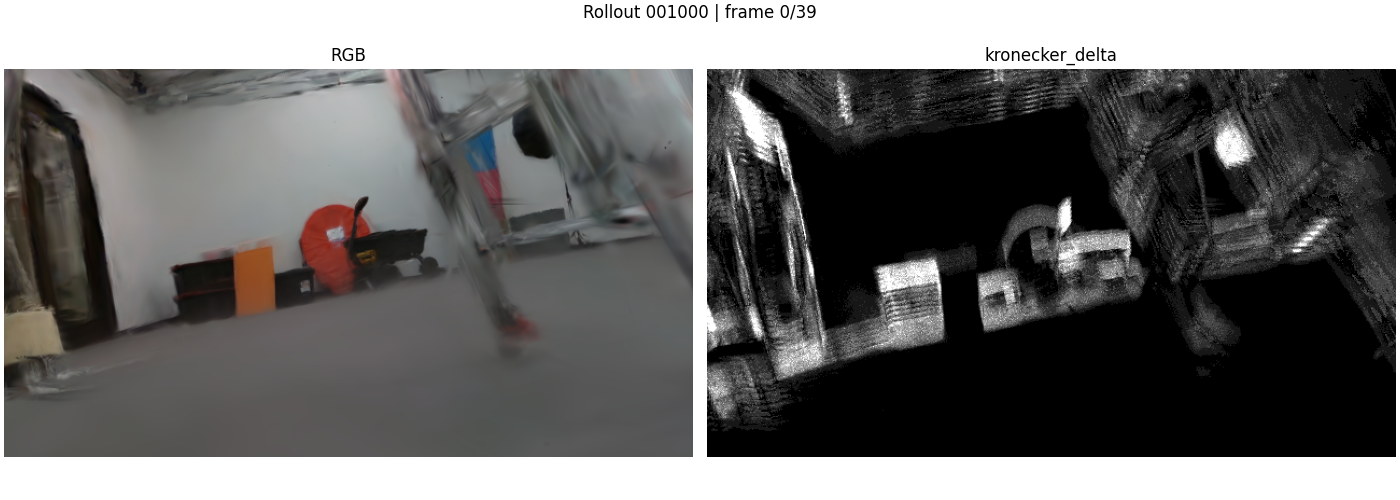

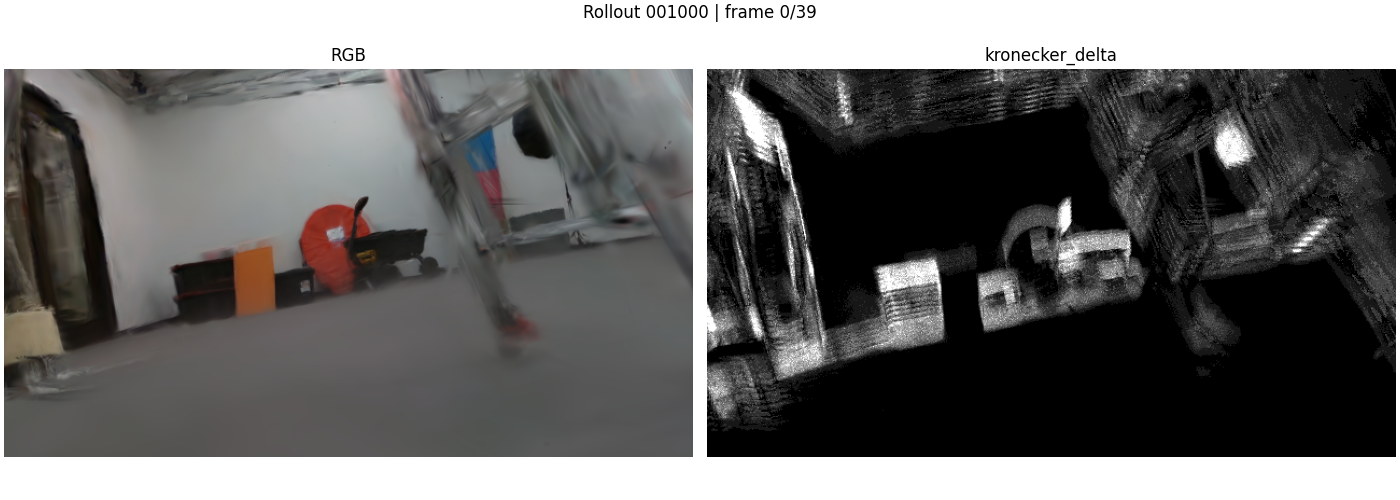

In [8]:
# Compare RGB and the selected event representation for one rollout.
import ipywidgets as widgets
from IPython.display import display

playback_interval_ms = 100

stack_suffix = event_pt.name.removeprefix(event_prefix)
rgb_pt = event_pt.parent.parent / "images" / f"images{stack_suffix}"
rgb_stack = torch.load(rgb_pt, weights_only=False, encoding="bytes")
event_stack = torch.load(event_pt, weights_only=False, encoding="bytes")
print(f"Loaded {rgb_pt} and {event_pt}")
if not 0 <= rollout_index < len(event_stack):
    raise IndexError(
        f"rollout_index {rollout_index} is outside the event stack range "
        f"[0, {len(event_stack) - 1}]"
    )
if rollout_index >= len(rgb_stack):
    raise IndexError(
        f"rollout_index {rollout_index} is outside the RGB stack range "
        f"[0, {len(rgb_stack) - 1}]"
    )

rgb_rollout = dch.decompress_data(dict(rgb_stack[rollout_index]), key="rgb")
event_rollout = dch.decompress_data(
    dict(event_stack[rollout_index]), key=inspection_modality
)
if rgb_rollout["rollout_id"] != event_rollout["rollout_id"]:
    raise ValueError(
        f"Rollout IDs do not match: {rgb_rollout['rollout_id']} != "
        f"{event_rollout['rollout_id']}"
    )

rgb_frames = rgb_rollout["rgb"]
event_frames = event_rollout[inspection_modality]
if len(rgb_frames) != len(event_frames):
    raise ValueError(
        f"Frame counts do not match: RGB={len(rgb_frames)}, "
        f"{inspection_modality}={len(event_frames)}"
    )
if len(rgb_frames) == 0:
    raise ValueError(f"Rollout {rgb_rollout['rollout_id']} has no frames")

first_event_image, event_cmap, event_vmin, event_vmax = project_event_frame(
    event_frames[0], inspection_modality)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
rgb_artist = axes[0].imshow(rgb_frames[0])
event_artist = axes[1].imshow(
    first_event_image, cmap=event_cmap, vmin=event_vmin, vmax=event_vmax
)
axes[0].set_title("RGB")
axes[1].set_title(inspection_modality)
for axis in axes:
    axis.axis("off")
frame_title = fig.suptitle("")

def show_aligned_frames(frame_index):
    rgb_artist.set_data(rgb_frames[frame_index])
    event_image, _, event_vmin, event_vmax = project_event_frame(
        event_frames[frame_index], inspection_modality)
    event_artist.set_data(event_image)
    event_artist.set_clim(event_vmin, event_vmax)
    frame_title.set_text(
        f"Rollout {rgb_rollout['rollout_id']} | frame {frame_index}/{len(rgb_frames) - 1}"
    )
    fig.canvas.draw_idle()

frame_slider = widgets.IntSlider(
    value=0, min=0, max=len(rgb_frames) - 1, step=1,
    description="Frame", continuous_update=False,
)
play_button = widgets.Play(
    value=0, min=0, max=len(rgb_frames) - 1, step=1,
    interval=playback_interval_ms, description="Play",
)
play_link = widgets.link((play_button, "value"), (frame_slider, "value"))
frame_slider.observe(
    lambda change: show_aligned_frames(change["new"]), names="value"
)
show_aligned_frames(0)
display(widgets.HBox([play_button, frame_slider]))
display(fig.canvas)

#### 4. Extract observation data.

We next extract the relevant data for each pilot. Users can configure their learned policies to use a variety of inputs. This function call extracts said inputs specific to each pilot from the raw rollout data. This allows you to test multiple learned policies from a single set of raw rollouts.

In [4]:
# Generate Observation Data
og.generate_observation_data(cohort,roster)

Generating observation data with subsample ratio 1.0 for...
 Cohort : robustness
 Roster : ['Maverick']
 Courses: ['traverse']

Output()

Generating network 'histNet' of type 'sifu' at path 
'/mnt/ssd/SousVide/cohorts/robustness/roster/Maverick/histNet.pt'...

Generating network 'commNet' of type 'svnet' at path 
'/mnt/ssd/SousVide/cohorts/robustness/roster/Maverick/commNet_rgb.pt'...

#### 5. Train the histNet

The best policy we found has two distinct networks that are trained separately. Here we train the first network, the histNet, which does a form of online rapid-motor-adaptation using a latent estimate of the drone's parameters. You can run the train_roster command multiple times to continue training the histNet. If you want to start from scratch, simply delete the histNet in the corresponding $course/roster/$pilot folder.

Use the plot function to review the current network's train/eval losses.

Using existing observation data...

Output()

Generating network 'histNet' of type 'sifu' at path 
'/mnt/ssd/SousVide/cohorts/robustness/roster/Maverick/histNet.pt'...

Generating network 'commNet' of type 'svnet' at path 
'/mnt/ssd/SousVide/cohorts/robustness/roster/Maverick/commNet_rgb.pt'...

======================================================================
Cohort : robustness             Network: histNet
======================================================================
----------------------------------------------------------------------
Student: Maverick   | Epochs: 200   | Data Size: 57344.0/832.0                
Time: 0h 7m 17s     | Train: 0.5015 | Test: 0.5359
======================================================================

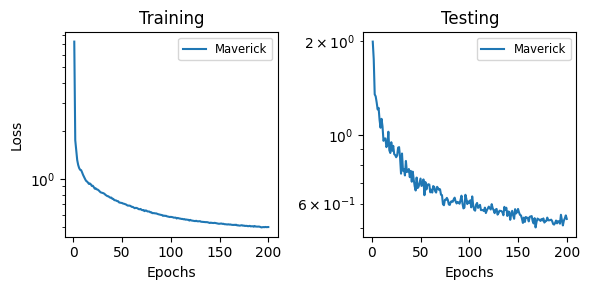

In [5]:
# Train the Policy
# tp.train_roster(
#     cohort,roster,"histNet",200,
#     dataloader_num_workers=8,cuda_prefetch=True,
#     numerical_mode="original")
tp.train_roster(cohort,roster,"histNet",200,numerical_mode="original")

# Plot the histNet losses
pl.plot_losses(cohort,roster,"histNet",use_log=True)

#### 6. Train the commNet

Here we train the second network, commNet, which contains the bulk of the parameters for the visuomotor policy. We also show a deployment evaluation option for training where we simulate the policy in FiGS at the save intervalsand use trajectory tracking error to grade policy performance. The best performing policy will be the final one that gets saved. Just like with histNet, re-running the train_roster function will load and train an existing network and if you want to start from scratch, delete the commNet file in the corresponding $course/roster/$pilot folder.

CommNet observations must be refreshed after HistNet training because the HistNet outputs have changed. Generate them in a separate step before using original numerical mode; this keeps the training inputs and RNG starting state fixed. The loop below trains one modality-specific checkpoint for every selected event representation, including the 5-channel signed and 10-channel polarity-separated voxel grids. Voxel inputs require an SVNet pilot such as Maverick or Iceman; DINO-based pilots remain RGB-only.

Use the plot function to review the current network's train/eval losses.

In [ ]:
# # Refresh CommNet inputs after HistNet training
# og.generate_observation_data(
#     cohort,roster,networks=["commNet"],image_modality="rgb")

# Train the Policy
tp.train_roster(
    cohort,roster,"commNet",300,
    deployment=(courses[0],scene,eval_method),
    image_modality="rgb",batch_size=64,
    dataloader_num_workers=8,cuda_prefetch=True,
    numerical_mode="original")
og.generate_observation_data(cohort,roster)
tp.train_roster(
    cohort,roster,"commNet",300,
    image_modality="rgb",
    regen=False,
    deployment=(courses[0],scene,eval_method),numerical_mode="original")


pl.plot_losses(
cohort,roster,"commNet",use_log=True,
image_modality="rgb")


# og.generate_observation_data(
#     cohort,roster,networks=["commNet"],
#     image_modality="grayscale")
# tp.train_roster(
#     cohort,roster,"commNet",300,
#     image_modality="grayscale",regen=False,
#     deployment=(courses[0],scene,eval_method),
#     numerical_mode="original")
# pl.plot_losses(
#     cohort,roster,"commNet",use_log=True,
#     image_modality="grayscale")


# for image_modality in event_modalities_to_train:
#     selected_event_options = {
#         image_modality: event_surface_options.get(image_modality, {})
#     }
#     og.generate_observation_data(
#         cohort,roster,networks=["commNet"],
#         image_modality=image_modality)
#     tp.train_roster(
#         cohort,roster,"commNet",300,
#         image_modality=image_modality,regen=False,
#         event_surface_options=selected_event_options,
#         deployment=(courses[0],scene,eval_method),
#         numerical_mode="original")
#     pl.plot_losses(
#         cohort,roster,"commNet",use_log=True,
#         image_modality=image_modality)

# og.generate_observation_data(
#     cohort, roster, networks=["commNet"],
#     image_modality="event_cloud",
#     event_cloud_options=cloud_options,
# )
# tp.train_roster(
#     cohort, roster, "commNet", 300,
#     image_modality="event_cloud",
#     event_cloud_options=cloud_options,
#     precision="float32",
#     compile_mode="none",
#     batch_size=32,
#     lr=0.0002,
#     deployment=(courses[0],scene,eval_method)
# )
# pl.plot_losses(
# cohort,roster,"commNet",use_log=True,
# image_modality="event_cloud")

Using existing observation data...

Output()

Generating network 'histNet' of type 'sifu' at path 
'/mnt/ssd/SousVide/cohorts/robustness/roster/Maverick/histNet.pt'...

Generating network 'commNet' of type 'svnet' at path 
'/mnt/ssd/SousVide/cohorts/robustness/roster/Maverick/commNet_rgb.pt'...

/mnt/ssd/SousVide/.venv/lib/python3.10/site-packages/torchmetrics/functional/image/lpips.py:293: UserWarning: 
Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly
passed to `torch.load`, forcing weights_only=False.
  self.load_state_dict(torch.load(model_path, map_location="cpu"), strict=False)

...

/mnt/ssd/SousVide/.venv/lib/python3.10/site-packages/torchmetrics/functional/image/lpips.py:293: UserWarning: 
Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly
passed to `torch.load`, forcing weights_only=False.
  self.load_state_dict(torch.load(model_path, map_location="cpu"), strict=False)

Loading latest checkpoint from load_dir

✅ Done loading checkpoint from outputs/mid_gate/splatfacto/2024-10-07_145741/nerfstudio_models/step-000029999.ckpt

Simulating expert:   0%|          | 0/10 [00:00<?, ?it/s]

Simulating Maverick:   0%|          | 0/10 [00:00<?, ?it/s]

Generating network 'histNet' of type 'sifu' at path '/mnt/ssd/SousVide/cohorts/robustness/roster/Maverick/histNet.pt'...
Generating network 'commNet' of type 'svnet' at path '/mnt/ssd/SousVide/cohorts/robustness/roster/Maverick/commNet_event_pseudo_gaussian.pt'...


/mnt/ssd/SousVide/.venv/lib/python3.10/site-packages/torchmetrics/functional/image/lpips.py:293: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  self.load_state_dict(torch.load(model_path, map_location="cpu"), strict=False)


Loading latest checkpoint from load_dir

✅ Done loading checkpoint from outputs/mid_gate/splatfacto/2024-10-07_145741/nerfstudio_models/step-000029999.ckpt

Simulating vrmpc rollout:   0%|          | 0/1420 [00:00<?, ?it/s]

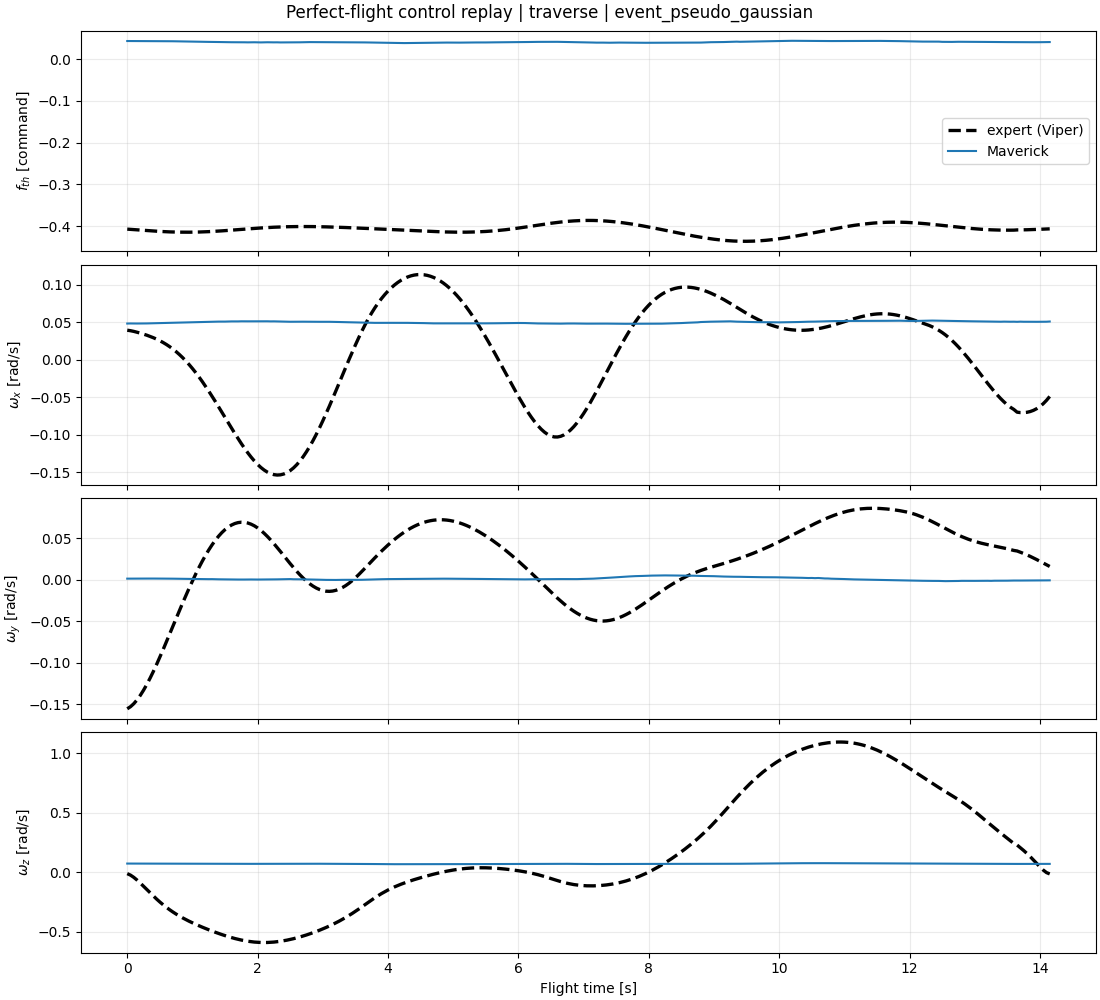

In [28]:
# Compare every selected policy with the expert on one identical perfect flight.
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import figs.dynamics.quadcopter_specifications as qs
import figs.utilities.config_helper as ch
import figs.utilities.transform_helper as th
from figs.control.vehicle_rate_mpc import VehicleRateMPC
from figs.dynamics.external_forces import ExternalForces
from figs.simulator import Simulator
from figs.tsplines.min_time_snap import MinTimeSnap

from sousvide.control.pilot import Pilot
import sousvide.control.network_factory as nf
from sousvide.synthesize.event_generator import V2ERolloutRecorder
from sousvide.synthesize.event_simulator import EventSimulator
from sousvide.synthesize.image_modality import (
    event_image_to_model_channels,
    is_event_cloud_modality,
    is_event_modality,
    is_grayscale_modality,
    rgb_to_grayscale,
    validate_visual_modality,
)

# Change this one value to test a different trained visual checkpoint.
perfect_flight_modality = "event_pseudo_gaussian"
perfect_flight_expert = "Viper"
perfect_flight_frame = "carl"
perfect_flight_method = "eval_single"
perfect_flight_course = courses[0]

perfect_flight_modality = validate_visual_modality(perfect_flight_modality)
if not roster:
    raise ValueError("roster must contain at least one learned pilot.")
if len(set(roster)) != len(roster):
    raise ValueError(f"roster contains duplicate pilot names: {roster!r}")
ideal_method = ch.get_config(perfect_flight_method, "methods")
if (
    any(ideal_method["randomization"]["parameters"])
    or any(ideal_method["randomization"]["initial"])
    or ideal_method["rollout"]["noise"]["model"] is not None
    or ideal_method["rollout"]["noise"]["sensor"] is not None
):
    raise ValueError(
        f"{perfect_flight_method!r} must have zero randomization and no noise."
    )

course_config = ch.get_config(perfect_flight_course, "courses")
expert_config = ch.get_config(perfect_flight_expert, "pilots")
frame_config = ch.get_config(perfect_flight_frame, "frames")
expert_hz = int(expert_config["track"]["hz"])

# Load and validate every requested checkpoint before starting the expensive flight.
workspace_path = Path(nf.__file__).resolve().parents[3]
replay_pilots = {}
for pilot_name in roster:
    pilot_config = ch.get_config(pilot_name, "pilots")
    pilot_hz = int(pilot_config.get("hz", expert_hz))
    if pilot_hz != expert_hz:
        raise ValueError(
            f"{pilot_name!r} is configured for {pilot_hz} Hz, but the expert "
            f"runs at {expert_hz} Hz."
        )
    pilot_path = workspace_path / "cohorts" / cohort / "roster" / pilot_name
    checkpoint_path = nf.get_network_load_path(
        str(pilot_path), "commNet", perfect_flight_modality
    )
    if not Path(checkpoint_path).is_file():
        raise FileNotFoundError(
            f"Cannot replay {pilot_name!r} with modality "
            f"{perfect_flight_modality!r}: no trained CommNet checkpoint "
            f"exists at {checkpoint_path!r}."
        )
    try:
        replay_pilot = Pilot(
            cohort,
            pilot_name,
            hz=pilot_hz,
            image_modality=perfect_flight_modality,
            event_cloud_options=(
                cloud_options
                if is_event_cloud_modality(perfect_flight_modality)
                else None
            ),
            require_commnet_weights=True,
        )
    except (FileNotFoundError, RuntimeError, ValueError) as error:
        raise type(error)(
            f"Cannot replay {pilot_name!r} with modality "
            f"{perfect_flight_modality!r}: {error}"
        ) from error
    if replay_pilot.hz != expert_hz:
        raise ValueError(
            f"{pilot_name!r} runs at {replay_pilot.hz} Hz, but the expert runs "
            f"at {expert_hz} Hz."
        )
    replay_pilot.policy.eval()
    replay_pilots[pilot_name] = replay_pilot

# Build the ideal full-course trajectory and its exact initial state.
minimum_time_snap = MinTimeSnap(
    course_config["waypoints"],
    expert_hz,
    expert_config["plan"]["kT"],
    expert_config["plan"]["use_l2_time"],
)
desired_times, desired_flat_outputs = minimum_time_snap.get_desired_trajectory()
external_forces = ExternalForces(course_config["forces"])
desired_trajectory = th.TsFO_to_tXU(
    desired_times,
    desired_flat_outputs,
    frame_config["mass"],
    frame_config["motor_thrust_coeff"],
    external_forces,
)
flight_t0 = float(desired_times[0])
flight_tf = float(desired_times[-1])
flight_x0 = np.asarray(desired_trajectory[0, 1:11], dtype=np.float64).copy()


class _ExpertCommandRecorder:
    """Record hidden event warm-up commands as well as logged commands."""

    def __init__(self, controller):
        self.controller = controller
        self.commands = []

    def __getattr__(self, name):
        return getattr(self.controller, name)

    def control(self, *args, **kwargs):
        command, timing = self.controller.control(*args, **kwargs)
        self.commands.append(np.asarray(command, dtype=np.float64).copy())
        return command, timing


expert_controller = _ExpertCommandRecorder(
    VehicleRateMPC(expert_config, course_config)
)
expert_controller.reset_memory(flight_x0)
expert_controller.update_frame(frame_config)

gsplat_config = ch.get_gsplat(scene)
event_recorder = None
if is_event_modality(perfect_flight_modality):
    simulator = EventSimulator(gsplat_config, ideal_method)
    expected_windows = int(round((flight_tf - flight_t0) * expert_hz))
    selected_surface_options = (
        None
        if is_event_cloud_modality(perfect_flight_modality)
        else {
            perfect_flight_modality: event_surface_options.get(
                perfect_flight_modality, {}
            )
        }
    )
    event_recorder = V2ERolloutRecorder(
        h5_path=None,
        expected_windows=expected_windows,
        retain_images=True,
        event_modalities=(perfect_flight_modality,),
        event_surface_options=selected_surface_options,
        event_cloud_options=(
            cloud_options
            if is_event_cloud_modality(perfect_flight_modality)
            else None
        ),
        stream_id=f"perfect:{perfect_flight_course}",
    )
else:
    simulator = Simulator(gsplat_config, ideal_method)

simulator.update_frame(frame_config)
simulator.update_forces(course_config["forces"])

try:
    if event_recorder is None:
        flight_data = simulator.simulate(
            expert_controller, flight_t0, flight_tf, flight_x0
        )
    else:
        simulation_hz = int(ideal_method["rollout"]["frequency"])
        if simulation_hz % expert_hz:
            raise ValueError(
                f"Simulation rate {simulation_hz} Hz is not divisible by "
                f"expert rate {expert_hz} Hz."
            )
        flight_data = simulator.simulate_with_events(
            expert_controller,
            flight_t0,
            flight_tf,
            flight_x0,
            event_recorder.process_frame,
            warmup_steps=simulation_hz // expert_hz,
            warmup_policy=expert_controller,
            image_modality="rgb",
        )
        event_frames = event_recorder.close_all()[perfect_flight_modality]
except Exception:
    if event_recorder is not None:
        event_recorder.abort()
    raise

flight_times, flight_states, expert_commands, flight_wrenches = flight_data[:4]
rgb_frames, depth_frames = flight_data[4:6]
sample_times = np.asarray(flight_times[:-1], dtype=np.float64)
expert_commands = np.asarray(expert_commands, dtype=np.float64)
sample_count = len(expert_commands)
if sample_count == 0:
    raise RuntimeError("The perfect-flight simulation produced no control samples.")
if expert_commands.shape != (sample_count, 4) or not np.all(
    np.isfinite(expert_commands)
):
    raise RuntimeError(
        f"The expert returned invalid command array shape {expert_commands.shape}."
    )
if not (
    len(sample_times)
    == len(flight_states) - 1
    == len(flight_wrenches)
    == len(rgb_frames)
    == len(depth_frames)
    == sample_count
):
    raise RuntimeError("Perfect-flight state, command, wrench, and image counts differ.")

recorded_commands = np.stack(expert_controller.commands)
if len(recorded_commands) < sample_count:
    raise RuntimeError("The expert command recorder missed logged flight commands.")
np.testing.assert_allclose(
    recorded_commands[-sample_count:], expert_commands, rtol=0.0, atol=0.0
)

if event_recorder is not None:
    visual_frames = event_frames
elif is_grayscale_modality(perfect_flight_modality):
    visual_frames = rgb_to_grayscale(rgb_frames)
else:
    visual_frames = rgb_frames
if len(visual_frames) != sample_count:
    raise RuntimeError(
        f"Expected {sample_count} {perfect_flight_modality} frames, got "
        f"{len(visual_frames)}."
    )

specification = qs.generate_specifications(frame_config)
hover_command = np.array(
    [
        -(
            specification["m"]
            * specification["g"]
            / (specification["Nrtr"] * specification["kt"])
        ),
        0.0,
        0.0,
        0.0,
    ],
    dtype=np.float64,
)
hidden_command_count = len(recorded_commands) - sample_count
if hidden_command_count not in (0, 1):
    raise RuntimeError(
        f"Expected zero or one hidden expert command, got {hidden_command_count}."
    )
initial_expert_command = (
    recorded_commands[0] if hidden_command_count == 1 else hover_command
)

command_outputs = {"expert": np.asarray(expert_commands)}
for pilot_name, replay_pilot in replay_pilots.items():
    replay_pilot.reset_memory(
        np.asarray(flight_states[0]),
        u0=initial_expert_command,
        fts0=np.asarray(flight_wrenches[0]),
    )
    predicted_commands = []
    previous_expert_command = initial_expert_command
    for sample_index in range(sample_count):
        visual_input = visual_frames[sample_index]
        if (
            event_recorder is not None
            and not is_event_cloud_modality(perfect_flight_modality)
        ):
            visual_input = event_image_to_model_channels(
                visual_input, perfect_flight_modality
            )
        command, _ = replay_pilot.control(
            sample_times[sample_index],
            np.asarray(flight_states[sample_index]),
            previous_expert_command,
            visual_input,
            np.asarray(depth_frames[sample_index]),
            np.asarray(flight_wrenches[sample_index]),
        )
        command = np.asarray(command, dtype=np.float64).reshape(-1)
        if command.shape != (4,) or not np.all(np.isfinite(command)):
            raise RuntimeError(
                f"{pilot_name!r} returned invalid command {command!r} at "
                f"sample {sample_index}."
            )
        predicted_commands.append(command)
        previous_expert_command = np.asarray(expert_commands[sample_index])
    predicted_commands = np.stack(predicted_commands)
    if predicted_commands.shape != (sample_count, 4):
        raise RuntimeError(
            f"{pilot_name!r} produced shape {predicted_commands.shape}; expected "
            f"({sample_count}, 4)."
        )
    command_outputs[pilot_name] = predicted_commands

thrust_outputs = {
    pilot_name: commands[:, 0]
    for pilot_name, commands in command_outputs.items()
}
body_rate_outputs = {
    pilot_name: commands[:, 1:4]
    for pilot_name, commands in command_outputs.items()
}

figure, axes = plt.subplots(
    4, 1, figsize=(11, 10), sharex=True, constrained_layout=True
)
component_labels = (
    r"$f_{th}$ [command]",
    r"$\omega_x$ [rad/s]",
    r"$\omega_y$ [rad/s]",
    r"$\omega_z$ [rad/s]",
)
for component_index, axis in enumerate(axes):
    axis.plot(
        sample_times,
        command_outputs["expert"][:, component_index],
        color="black",
        linestyle="--",
        linewidth=2.4,
        label=f"expert ({perfect_flight_expert})",
    )
    for pilot_name in roster:
        axis.plot(
            sample_times,
            command_outputs[pilot_name][:, component_index],
            linewidth=1.5,
            label=pilot_name,
        )
    axis.set_ylabel(component_labels[component_index])
    axis.grid(alpha=0.25)
axes[0].legend(loc="best")
axes[-1].set_xlabel("Flight time [s]")
figure.suptitle(
    f"Perfect-flight control replay | {perfect_flight_course} | "
    f"{perfect_flight_modality}"
)
plt.show()


#### 7. Evaluate using FiGS

Run an evalution using FiGS simulations and plot some useful data. Video of last policy rollout(s) can be found in $course/deployment_data.

/mnt/ssd/SousVide/.venv/lib/python3.10/site-packages/torchmetrics/functional/image/lpips.py:293: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  self.load_state_dict(torch.load(model_path, map_location="cpu"), strict=False)


Loading latest checkpoint from load_dir

✅ Done loading checkpoint from outputs/mid_gate/splatfacto/2024-10-07_145741/nerfstudio_models/step-000029999.ckpt

Simulating expert:   0%|          | 0/10 [00:00<?, ?it/s]

Simulating vrmpc rollout:   0%|          | 0/1420 [00:00<?, ?it/s]

...

Simulating Maverick rollout:   0%|          | 0/1420 [00:00<?, ?it/s]

Simulating Maverick rollout:   0%|          | 0/1420 [00:00<?, ?it/s]

Simulating Maverick rollout:   0%|          | 0/1420 [00:00<?, ?it/s]

Plotting trajectories for expert...

/mnt/ssd/SousVide/src/sousvide/visualize/plot_3D.py:24: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure()


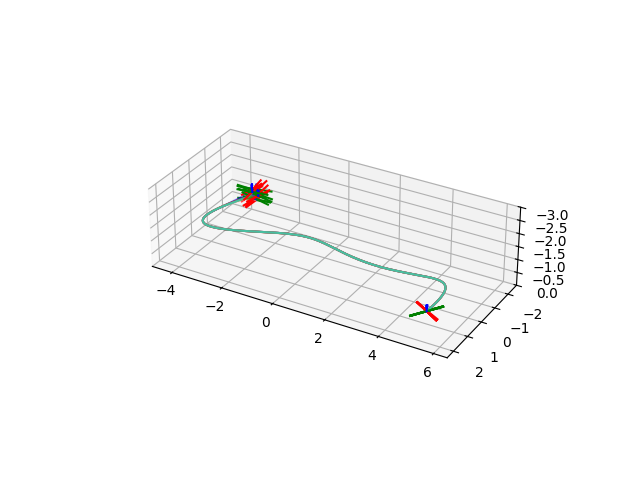

Plotting trajectories for Maverick...

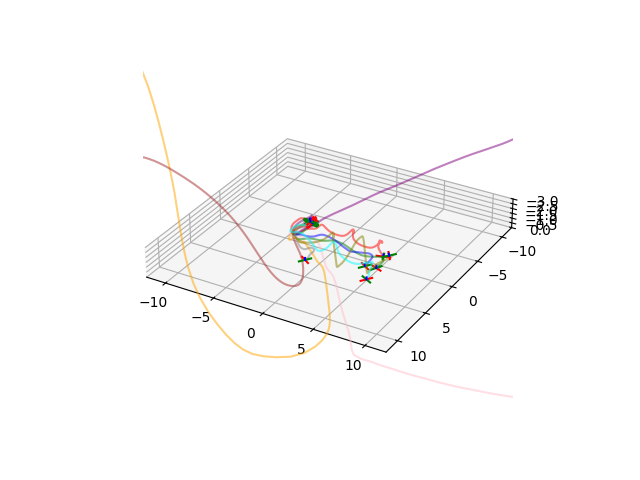

                      Deployment Summary                      
┏━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┓
┃ Pilot    ┃ TTE Mean ┃ TTE Best ┃  PP  ┃ Hz Mean ┃ Hz Worst ┃
┡━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━╇━━━━━━━━━╇━━━━━━━━━━┩
│ expert   │   7.26   │   7.23   │ 0.00 │  0.81   │   0.78   │
│ Maverick │  67.46   │   7.26   │ 0.00 │  0.14   │   0.14   │
└──────────┴──────────┴──────────┴──────┴─────────┴──────────┘

In [25]:
# Simulate in FiGS
debug_deployment = False  # Set True to show the live policy image and body-rate output.
deployment_modality = event_modalities_to_train[1]
# deployment_modality is selected in the configuration cell.
for course in courses:
    # df.deploy_roster(
    #     cohort,course,scene,eval_method,roster,mode="visualize",
    #     image_modality=deployment_modality,
    #     event_surface_options={
    #         deployment_modality: event_surface_options.get(
    #             deployment_modality, {})
    #     },
    #     debug=debug_deployment)
    df.deploy_roster(
        cohort, course, scene, eval_method, roster,
        image_modality="event_cloud",
        event_cloud_options=cloud_options,
        debug=debug_deployment,
        mode="visualize"
    )
    # df.deploy_roster(
    #     cohort, course, scene, eval_method, roster,
    #     image_modality="rgb",
    #     debug=debug_deployment,
    #     mode="visualize"
    # )
    pl.plot_deployments(cohort,course,roster,plot_show=True)

    
# for course in courses:
#     df.deploy_roster(
#         cohort,course,scene,eval_method,roster,mode="visualize",
#         image_modality="grayscale",
#         debug=debug_deployment)
#     pl.plot_deployments(cohort,course,roster,plot_show=True)